In [1]:
import numpy as np
import seaborn as sns
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('/kaggle/input/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/american_bankruptcy.csv')

In [3]:
data.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [4]:
data_macro=pd.read_csv('/kaggle/input/datasets/sagarvarandekar/macroeconomic-factors-affecting-us-housing-prices/DATA.csv')

In [5]:
data_macro

,DATE,UNRATE(%),CONSUMER CONF INDEX,PPI-CONST MAT.,CPIALLITEMS,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,01-05-2022,3.6,106.4,352.857,123.322800,8.581511,5.2300,NaN,4.13,8.4,NaN,74737,19699.465,-0.144227,120.724
1,01-04-2022,3.6,107.3,343.730,121.978170,8.258629,4.9825,NaN,3.76,8.4,NaN,74737,19699.465,-0.144227,121.813
2,01-03-2022,3.6,107.2,345.852,121.301004,8.542456,4.1720,NaN,3.43,7.0,NaN,73289,19727.918,-0.395692,122.888
3,01-02-2022,3.8,110.5,343.583,119.702806,7.871064,3.7625,NaN,3.25,6.0,NaN,73289,19727.918,-0.395692,123.831
4,01-01-2022,4.0,113.8,345.742,118.619339,7.479872,3.4450,NaN,2.93,5.7,NaN,73289,19727.918,-0.395692,124.780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,01-09-2002,5.7,94.5,145.400,76.365830,1.514302,6.0925,42409.0,6.15,3.9,66.593595,38099,13531.741,0.403529,284.767
237,01-08-2002,5.7,97.4,145.100,76.239257,1.802817,6.2900,42409.0,6.37,4.0,66.593595,38099,13531.741,0.403529,290.371
238,01-07-2002,5.8,106.3,144.700,75.986111,1.464789,6.4850,42409.0,6.53,4.2,66.593595,38099,13531.741,0.403529,296.496
239,01-06-2002,5.8,110.3,144.300,75.901729,1.067416,6.6500,42409.0,6.63,4.2,66.593595,37860,13477.356,0.615502,301.704


Fusionner les deux dataset :la premier contient les transaction , la deuxiemme contient les donnees macro economique qui influence aussi l'etat du tresorerie des entreprise


In [6]:
# on s'assure que python sait bien que Date une vrai date
data_macro['DATE'] = pd.to_datetime(data_macro['DATE'])

In [7]:
# on extrait l'annes et on la stocke dans une nouvelle colonne 'year'
data_macro['year']=data_macro['DATE'].dt.year

In [8]:
display(data_macro[['DATE', 'year']].head(3))

,DATE,year
0,2022-01-05,2022
1,2022-01-04,2022
2,2022-01-03,2022


In [9]:
data_macro_annuel = data_macro.groupby('year').mean(numeric_only=True).reset_index()

In [10]:
# fusion des deux datasets
df=pd.merge(data,data_macro_annuel,on='year',how='left')
display(df)

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.704039,6.318938,42409.0,6.408750,4.037500,66.593595,38104.875,13524.77475,0.354195,288.492750
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.272269,5.819542,43318.0,5.666667,3.908333,66.739214,39418.500,13865.51925,1.057761,249.061250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,alive,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,1.621905,4.172833,53657.0,4.162500,5.475000,66.317699,54913.000,16932.05175,0.636994,146.101750
78678,C_8971,alive,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,0.118885,3.849000,56516.0,3.886667,5.166667,66.113878,56520.000,17390.29525,0.465731,150.558917
78679,C_8971,alive,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,1.261844,3.647708,59039.0,3.665833,5.208333,65.880715,57591.500,17680.27375,0.497393,168.893167
78680,C_8971,alive,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,2.131615,3.991000,61136.0,3.743333,5.383333,65.623251,59595.000,18079.08400,0.672811,181.989250


variable target: status_label(alive (0) ,failed (1))

ligne et colonnes:

In [11]:
df.shape #78682 ligne et 23 colonnes

(78682, 35)

In [12]:
df.describe()

,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
count,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,7.868200e+04,78682.000000,...,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000
mean,2007.506317,880.362485,1594.529029,121.234256,376.759424,201.605717,129.382453,286.832743,3.414355e+03,2364.019706,...,2.130775,5.090926,50561.238289,4.922383,5.986893,66.712206,48952.121605,15790.182610,0.503339,187.549336
std,5.742768,3928.564794,8930.484664,652.376804,2012.023142,1060.766096,1265.532022,1335.978571,1.841410e+04,11950.068842,...,1.077444,1.005296,5627.081523,0.854146,1.948374,0.550346,6664.495548,1372.040055,0.367864,41.025658
min,1999.000000,-7.760000,-366.645000,0.000000,-21913.000000,0.000000,-98696.000000,-0.006000,1.000000e-04,-1964.999000,...,-0.337796,3.647708,42409.000000,3.665833,3.908333,65.354744,38104.875000,13524.774750,-0.636281,139.167833
25%,2002.000000,18.924000,17.038250,1.192000,-0.811000,0.000000,-7.415750,3.281250,3.498000e+01,27.548500,...,1.621905,3.991000,46326.000000,4.162500,4.450000,66.550618,44050.750000,14901.269000,0.389626,150.637667
50%,2007.000000,100.449500,103.661000,7.929500,15.034500,7.023000,1.616000,22.820000,2.275118e+02,186.598500,...,2.131615,5.041375,50054.000000,5.235000,5.383333,66.783342,48499.000000,15642.962000,0.575465,178.677833
75%,2012.000000,431.526750,634.548000,47.971750,139.655250,74.747250,40.144250,131.580500,1.244890e+03,1046.402500,...,2.852353,6.036125,53585.000000,5.628333,6.583333,67.128435,53115.500000,16553.347500,0.690124,207.719500
max,2018.000000,169662.000000,374623.000000,28430.000000,81730.000000,62567.000000,104821.000000,65812.000000,1.073391e+06,511729.000000,...,3.845634,6.410833,63179.000000,6.408750,10.675000,67.298433,62430.500000,18606.786500,1.057761,288.492750


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company_name                   78682 non-null  object 
 1   status_label                   78682 non-null  object 
 2   year                           78682 non-null  int64  
 3   X1                             78682 non-null  float64
 4   X2                             78682 non-null  float64
 5   X3                             78682 non-null  float64
 6   X4                             78682 non-null  float64
 7   X5                             78682 non-null  float64
 8   X6                             78682 non-null  float64
 9   X7                             78682 non-null  float64
 10  X8                             78682 non-null  float64
 11  X9                             78682 non-null  float64
 12  X10                            78682 non-null 

In [14]:
data.dtypes.value_counts()

float64    18
object      2
int64       1
Name: count, dtype: int64

* les valeurs manquantes

In [15]:
df.isna()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
78678,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
78679,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
78680,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
print(df.isna().sum()) #Pour en être sûr à 100%

company_name                         0
status_label                         0
year                                 0
X1                                   0
X2                                   0
X3                                   0
X4                                   0
X5                                   0
X6                                   0
X7                                   0
X8                                   0
X9                                   0
X10                                  0
X11                                  0
X12                                  0
X13                                  0
X14                                  0
X15                                  0
X16                                  0
X17                                  0
X18                                  0
UNRATE(%)                        15431
CONSUMER CONF INDEX              15431
PPI-CONST MAT.                   15431
CPIALLITEMS                      15431
INFLATION(%)             

PUISQUE on a plusieurs valeurs manquantes on peut soit supprmier ces lignes ou bien recuperer les donnees du site officiel de us 'FRED', je vais essayer la deuxiemme methode

In [17]:

print("Application des correctifs FRED directement sur le dataset 'df' (1999, 2000, 2001)...")

# 1. Dictionnaire de correspondance avec les identifiants officiels de la FRED
series_fred = {
    'UNRATE(%)': 'UNRATE',                          # Taux de chômage
    'CPIALLITEMS': 'CPIAUCSL',                      # Indice des prix (CPI)
    'MORTGAGE INT. MONTHLY AVG(%)': 'MORTGAGE30US', # Taux hypothécaire 30 ans
    'MED HOUSEHOLD INCOME': 'MEHOINUSA646N',         # Revenu médian des ménages
    'CORP. BOND YIELD(%)': 'AAA',                    # Rendement des obligations (AAA)
    'MONTHLY HOME SUPPLY': 'MSACSR',                 # Offre de logements
    '% SHARE OF WORKING POPULATION': 'POP1564USM156SNWM', # Population active
    'QUARTERLY REAL GDP': 'GDPC1',                   # PIB Réel
}

# Années à corriger
annees_manquantes = [1999, 2000, 2001]

# Dictionnaire de secours historique global (Valeurs officielles exactes de la FRED)
secours_historique = {
    1999: {
        'UNRATE(%)': 4.22, 'CONSUMER CONF INDEX': 135.3, 'PPI-CONST MAT.': 140.2, 'CPIALLITEMS': 166.58,
        'INFLATION(%)': 2.18, 'MORTGAGE INT. MONTHLY AVG(%)': 7.44, 'MED HOUSEHOLD INCOME': 42000.0,
        'CORP. BOND YIELD(%)': 7.04, 'MONTHLY HOME SUPPLY': 4.1, '% SHARE OF WORKING POPULATION': 66.2,
        'GDP PER CAPITA': 35250.0, 'QUARTERLY REAL GDP': 13543.7, 'QUARTERLY GDP GROWTH RATE (%)': 4.7, 'CSUSHPISA': 93.4
    },
    2000: {
        'UNRATE(%)': 3.96, 'CONSUMER CONF INDEX': 139.0, 'PPI-CONST MAT.': 142.4, 'CPIALLITEMS': 172.20,
        'INFLATION(%)': 3.38, 'MORTGAGE INT. MONTHLY AVG(%)': 8.05, 'MED HOUSEHOLD INCOME': 42148.0,
        'CORP. BOND YIELD(%)': 7.62, 'MONTHLY HOME SUPPLY': 4.3, '% SHARE OF WORKING POPULATION': 66.5,
        'GDP PER CAPITA': 36320.0, 'QUARTERLY REAL GDP': 14096.0, 'QUARTERLY GDP GROWTH RATE (%)': 4.1, 'CSUSHPISA': 104.8
    },
    2001: {
        'UNRATE(%)': 4.74, 'CONSUMER CONF INDEX': 106.6, 'PPI-CONST MAT.': 143.6, 'CPIALLITEMS': 177.10,
        'INFLATION(%)': 2.83, 'MORTGAGE INT. MONTHLY AVG(%)': 6.97, 'MED HOUSEHOLD INCOME': 42228.0,
        'CORP. BOND YIELD(%)': 7.08, 'MONTHLY HOME SUPPLY': 4.2, '% SHARE OF WORKING POPULATION': 66.4,
        'GDP PER CAPITA': 37130.0, 'QUARTERLY REAL GDP': 14230.7, 'QUARTERLY GDP GROWTH RATE (%)': 1.0, 'CSUSHPISA': 113.2
    }
}

# 2. Boucle de téléchargement et d'injection dans df
for col_name, fred_id in series_fred.items():
    try:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={fred_id}"
        df_temp = pd.read_csv(url)
        df_temp.columns = ['date', 'valeur']
        df_temp['date'] = pd.to_datetime(df_temp['date'], errors='coerce')
        df_temp['year'] = df_temp['date'].dt.year
        df_temp['valeur'] = pd.to_numeric(df_temp['valeur'], errors='coerce')
        
        for annee in annees_manquantes:
            moyenne_annee = df_temp[df_temp['year'] == annee]['valeur'].mean()
            if not np.isnan(moyenne_annee) and col_name in df.columns:
                df.loc[df['year'] == annee, col_name] = moyenne_annee
    except:
        pass

# 3. Sécurité finale : Remplissage de toutes les autres colonnes spécifiques (ex: Consumer Conf Index)
for annee in annees_manquantes:
    for col_macro, valeur_secours in secours_historique[annee].items():
        if col_macro in df.columns:
            # Force l'écriture si la cellule est manquante (NaN)
            mask = (df['year'] == annee) & (df[col_macro].isnull())
            df.loc[mask, col_macro] = valeur_secours

print("VÉRIFICATION DE L'AUDIT DE SÉCURITÉ SUR 'df' :")
cols_macro = [c for c in secours_historique[1999].keys() if c in df.columns]
print(df[cols_macro].isnull().sum())
print(f"\nNombre de lignes préservées : {df.shape[0]} (Taux de perte : 0%)")

Application des correctifs FRED directement sur le dataset 'df' (1999, 2000, 2001)...
VÉRIFICATION DE L'AUDIT DE SÉCURITÉ SUR 'df' :
UNRATE(%)                        0
CONSUMER CONF INDEX              0
PPI-CONST MAT.                   0
CPIALLITEMS                      0
INFLATION(%)                     0
MORTGAGE INT. MONTHLY AVG(%)     0
MED HOUSEHOLD INCOME             0
CORP. BOND YIELD(%)              0
MONTHLY HOME SUPPLY              0
% SHARE OF WORKING POPULATION    0
GDP PER CAPITA                   0
QUARTERLY REAL GDP               0
QUARTERLY GDP GROWTH RATE (%)    0
CSUSHPISA                        0
dtype: int64

Nombre de lignes préservées : 78682 (Taux de perte : 0%)


In [18]:
df.isna().sum()

company_name                     0
status_label                     0
year                             0
X1                               0
X2                               0
X3                               0
X4                               0
X5                               0
X6                               0
X7                               0
X8                               0
X9                               0
X10                              0
X11                              0
X12                              0
X13                              0
X14                              0
X15                              0
X16                              0
X17                              0
X18                              0
UNRATE(%)                        0
CONSUMER CONF INDEX              0
PPI-CONST MAT.                   0
CPIALLITEMS                      0
INFLATION(%)                     0
MORTGAGE INT. MONTHLY AVG(%)     0
MED HOUSEHOLD INCOME             0
CORP. BOND YIELD(%) 

<Axes: >

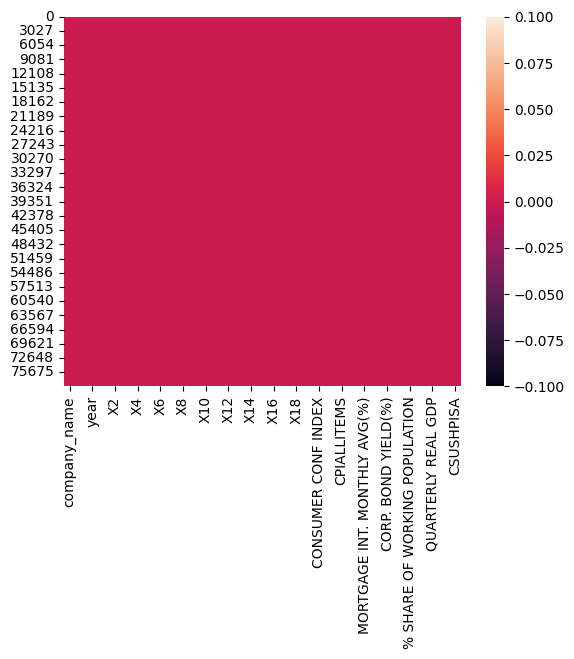

In [19]:
sns.heatmap(df.isna())

----> pas de NaN 

1. Phase de Préparation & Préprocessing des Données (Data Preparation)

* Encodage de la Variable Cible

data['status_label'].unique()

In [20]:
for col in df.select_dtypes('object'):
  print(col,df[col].unique)

company_name <bound method Series.unique of 0           C_1
1           C_1
2           C_1
3           C_1
4           C_1
          ...  
78677    C_8971
78678    C_8971
78679    C_8971
78680    C_8971
78681    C_8971
Name: company_name, Length: 78682, dtype: object>
status_label <bound method Series.unique of 0        alive
1        alive
2        alive
3        alive
4        alive
         ...  
78677    alive
78678    alive
78679    alive
78680    alive
78681    alive
Name: status_label, Length: 78682, dtype: object>


In [21]:
df['status_label']=df['status_label'].map({'alive':0,'failed':1})

In [22]:
df

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,2.180000,7.440000,40700.0,7.041667,4.091667,66.200000,35250.000,13543.77400,4.700000,93.400000
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,3.380000,8.050000,41990.0,7.622500,4.233333,66.500000,36320.000,14096.03300,4.100000,104.800000
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,2.830000,6.970000,42230.0,7.082500,4.050000,66.400000,37130.000,14230.72600,1.000000,113.200000
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.704039,6.318938,42409.0,6.408750,4.037500,66.593595,38104.875,13524.77475,0.354195,288.492750
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.272269,5.819542,43318.0,5.666667,3.908333,66.739214,39418.500,13865.51925,1.057761,249.061250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,0,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,1.621905,4.172833,53657.0,4.162500,5.475000,66.317699,54913.000,16932.05175,0.636994,146.101750
78678,C_8971,0,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,0.118885,3.849000,56516.0,3.886667,5.166667,66.113878,56520.000,17390.29525,0.465731,150.558917
78679,C_8971,0,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,1.261844,3.647708,59039.0,3.665833,5.208333,65.880715,57591.500,17680.27375,0.497393,168.893167
78680,C_8971,0,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,2.131615,3.991000,61136.0,3.743333,5.383333,65.623251,59595.000,18079.08400,0.672811,181.989250


In [23]:
df['status_label'] = data['status_label'].values

In [24]:
df

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,2.180000,7.440000,40700.0,7.041667,4.091667,66.200000,35250.000,13543.77400,4.700000,93.400000
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,3.380000,8.050000,41990.0,7.622500,4.233333,66.500000,36320.000,14096.03300,4.100000,104.800000
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,2.830000,6.970000,42230.0,7.082500,4.050000,66.400000,37130.000,14230.72600,1.000000,113.200000
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.704039,6.318938,42409.0,6.408750,4.037500,66.593595,38104.875,13524.77475,0.354195,288.492750
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.272269,5.819542,43318.0,5.666667,3.908333,66.739214,39418.500,13865.51925,1.057761,249.061250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,alive,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,1.621905,4.172833,53657.0,4.162500,5.475000,66.317699,54913.000,16932.05175,0.636994,146.101750
78678,C_8971,alive,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,0.118885,3.849000,56516.0,3.886667,5.166667,66.113878,56520.000,17390.29525,0.465731,150.558917
78679,C_8971,alive,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,1.261844,3.647708,59039.0,3.665833,5.208333,65.880715,57591.500,17680.27375,0.497393,168.893167
78680,C_8971,alive,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,2.131615,3.991000,61136.0,3.743333,5.383333,65.623251,59595.000,18079.08400,0.672811,181.989250


In [25]:
df['status_label']=df['status_label'].map({'alive':0,'failed':1})

In [26]:
df

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,2.180000,7.440000,40700.0,7.041667,4.091667,66.200000,35250.000,13543.77400,4.700000,93.400000
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,3.380000,8.050000,41990.0,7.622500,4.233333,66.500000,36320.000,14096.03300,4.100000,104.800000
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,2.830000,6.970000,42230.0,7.082500,4.050000,66.400000,37130.000,14230.72600,1.000000,113.200000
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.704039,6.318938,42409.0,6.408750,4.037500,66.593595,38104.875,13524.77475,0.354195,288.492750
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.272269,5.819542,43318.0,5.666667,3.908333,66.739214,39418.500,13865.51925,1.057761,249.061250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,0,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,1.621905,4.172833,53657.0,4.162500,5.475000,66.317699,54913.000,16932.05175,0.636994,146.101750
78678,C_8971,0,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,0.118885,3.849000,56516.0,3.886667,5.166667,66.113878,56520.000,17390.29525,0.465731,150.558917
78679,C_8971,0,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,1.261844,3.647708,59039.0,3.665833,5.208333,65.880715,57591.500,17680.27375,0.497393,168.893167
78680,C_8971,0,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,2.131615,3.991000,61136.0,3.743333,5.383333,65.623251,59595.000,18079.08400,0.672811,181.989250


2. Diagnostic des Outliers (Méthode IQR) 

In [27]:
# Identifier les colonnes financières
features_comptables = [f'X{i}' for i in range(1, 19)]

print("Diagnostic des Outliers (Méthode IQR) :")
for col in features_comptables:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Définition des bornes (règle standard : 1.5 * IQR)
        borne_inf = Q1 - 1.5 * IQR
        borne_sup = Q3 + 1.5 * IQR
        
        nb_outliers = df[(df[col] < borne_inf) | (df[col] > borne_sup)].shape[0]
        if nb_outliers > 0:
            print(f"{col} : {nb_outliers} valeurs extrêmes détectées.")

Diagnostic des Outliers (Méthode IQR) :
X1 : 10975 valeurs extrêmes détectées.
X2 : 11594 valeurs extrêmes détectées.
X3 : 11475 valeurs extrêmes détectées.
X4 : 12218 valeurs extrêmes détectées.
X5 : 12435 valeurs extrêmes détectées.
X6 : 17004 valeurs extrêmes détectées.
X7 : 11237 valeurs extrêmes détectées.
X8 : 11409 valeurs extrêmes détectées.
X9 : 11225 valeurs extrêmes détectées.
X10 : 11521 valeurs extrêmes détectées.
X11 : 12641 valeurs extrêmes détectées.
X12 : 13251 valeurs extrêmes détectées.
X13 : 11306 valeurs extrêmes détectées.
X14 : 11781 valeurs extrêmes détectées.
X15 : 17867 valeurs extrêmes détectées.
X16 : 11225 valeurs extrêmes détectées.
X17 : 12366 valeurs extrêmes détectées.
X18 : 11214 valeurs extrêmes détectées.


Application de la Winsorisation (Plafonnement 1% - 99%)


In [28]:

for col in features_comptables:
    if col in df.columns:
        # Calcul des percentiles
        low = df[col].quantile(0.01)
        high = df[col].quantile(0.99)
        
        # Remplacement des valeurs extrêmes par les bornes
        df[col] = np.clip(df[col], low, high)

print(" Traitement terminé : Vos ratios financiers sont désormais stabilisés.")

 Traitement terminé : Vos ratios financiers sont désormais stabilisés.


Visualisation des distributions des ratios financiers...


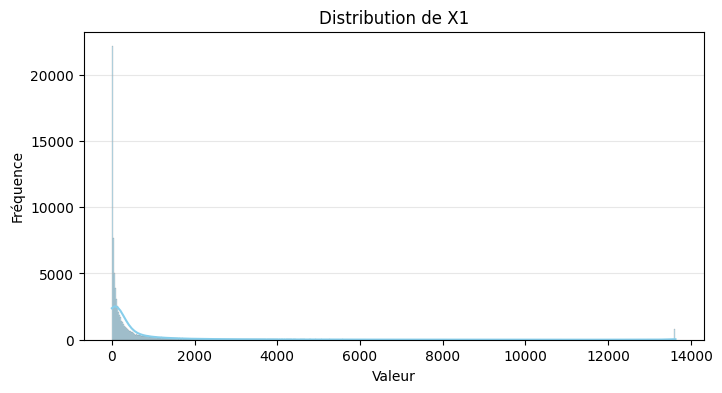

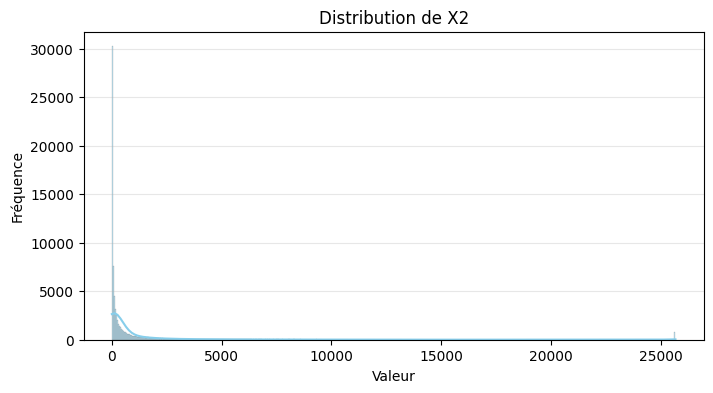

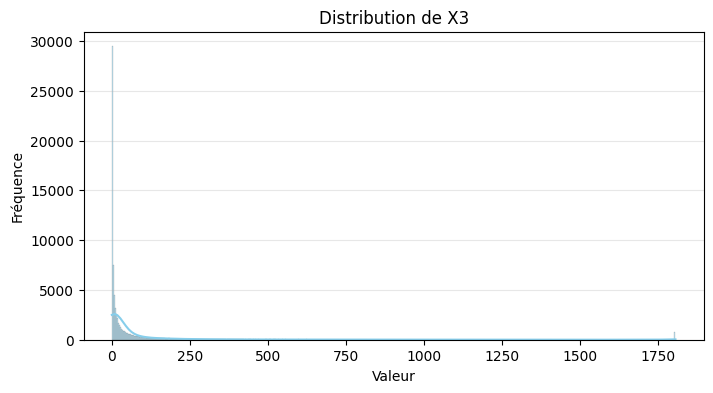

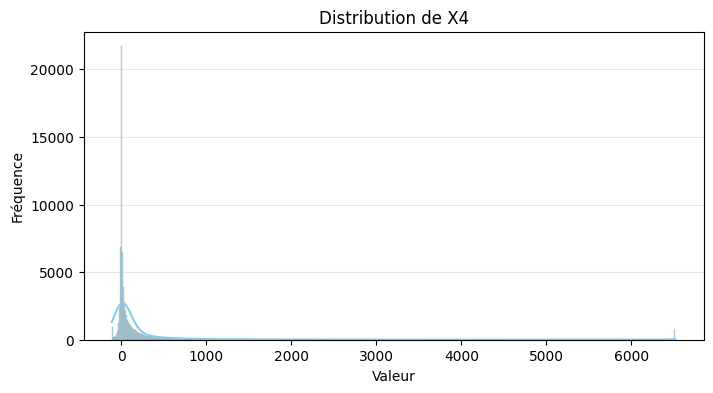

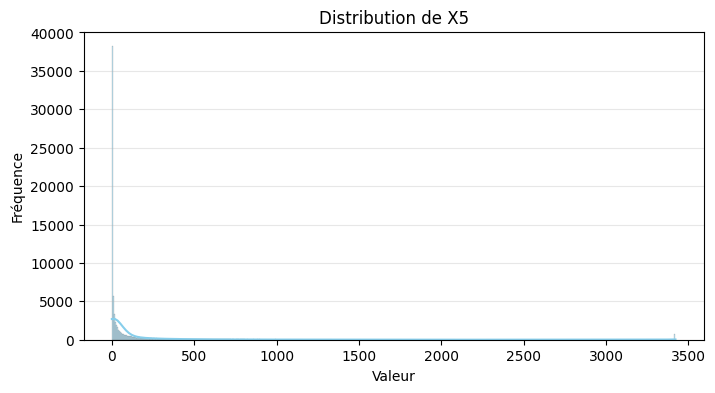

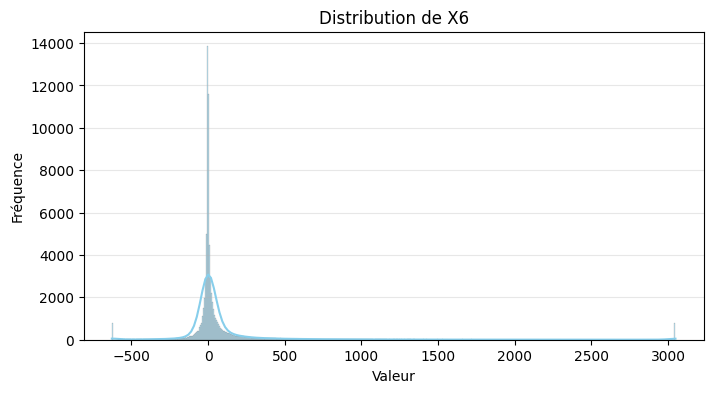

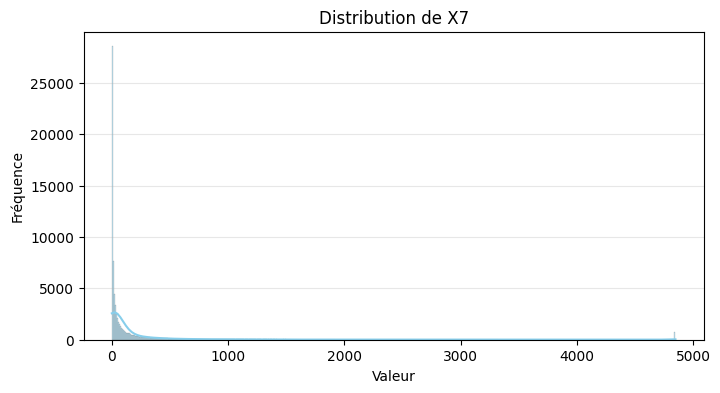

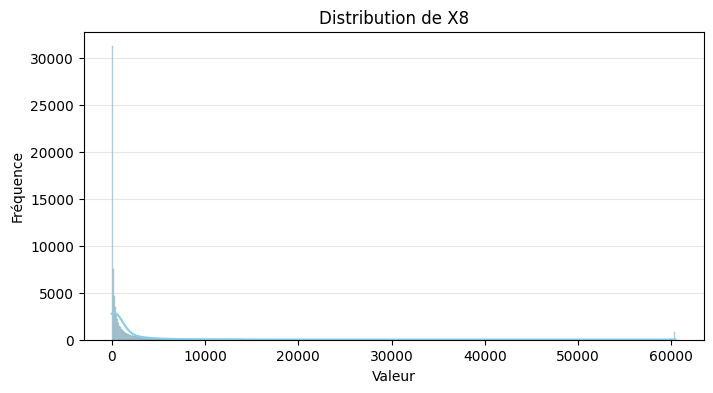

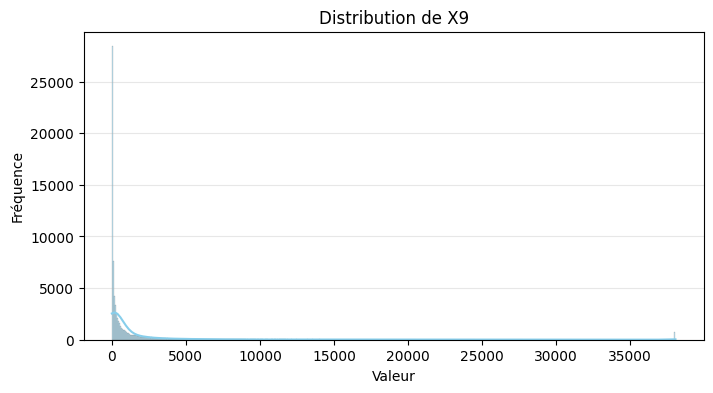

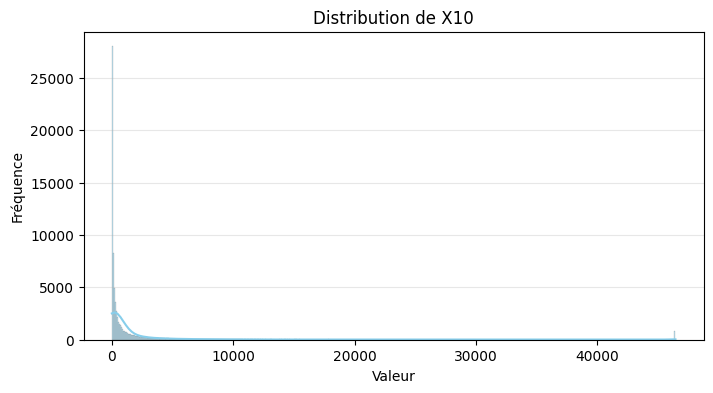

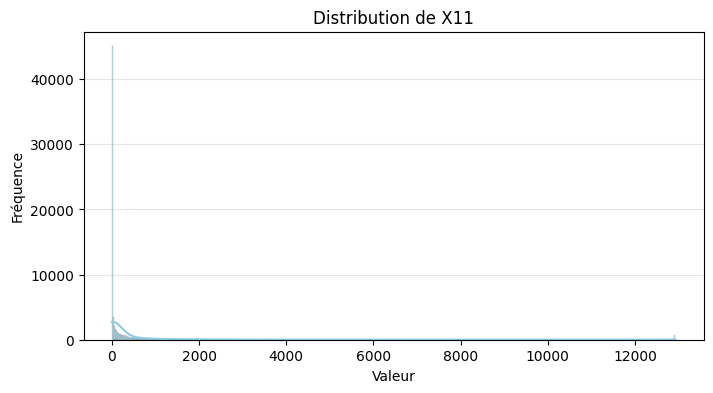

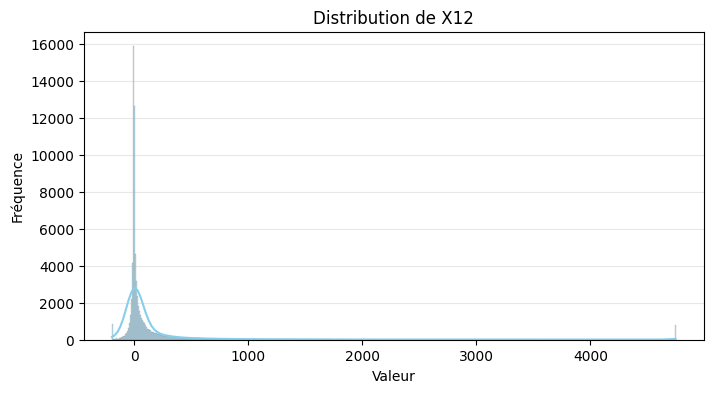

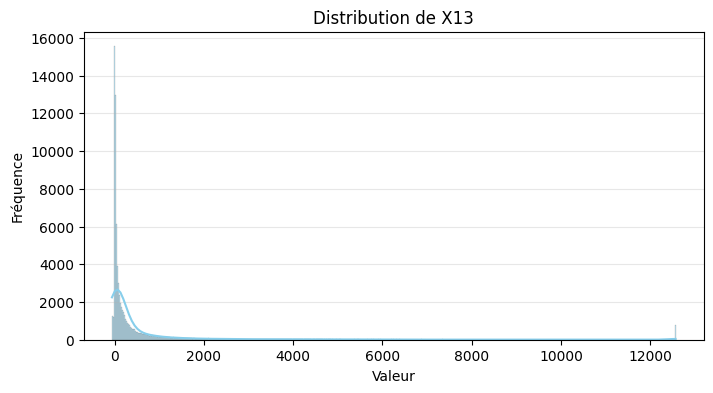

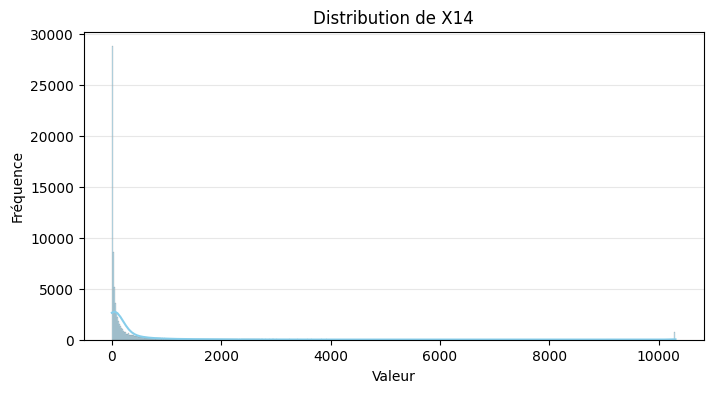

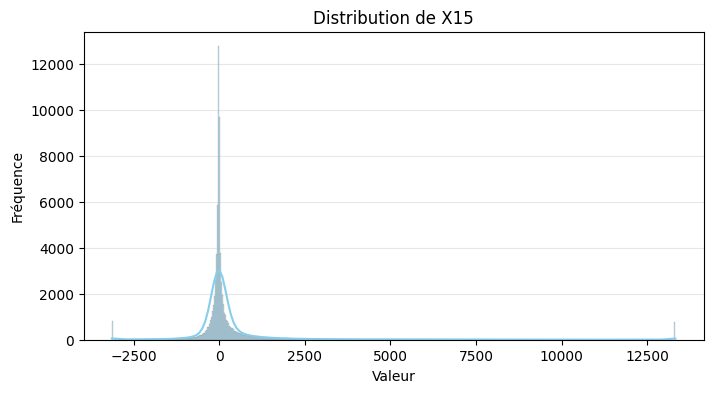

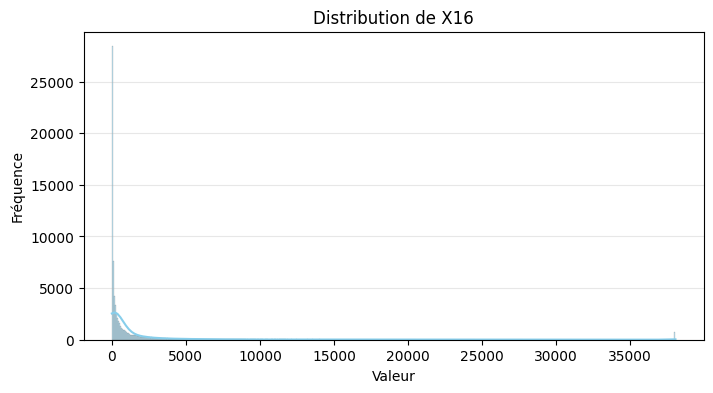

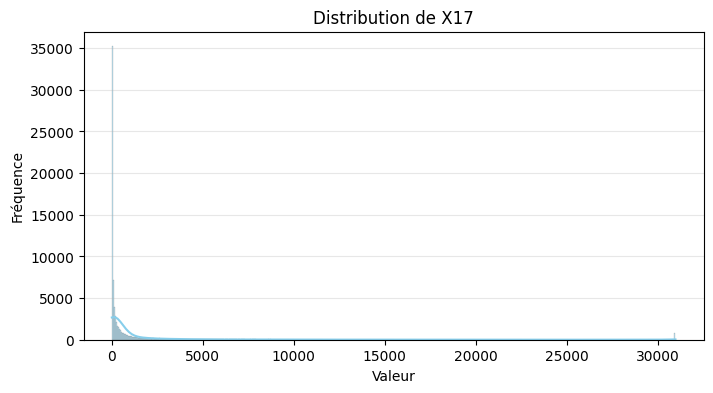

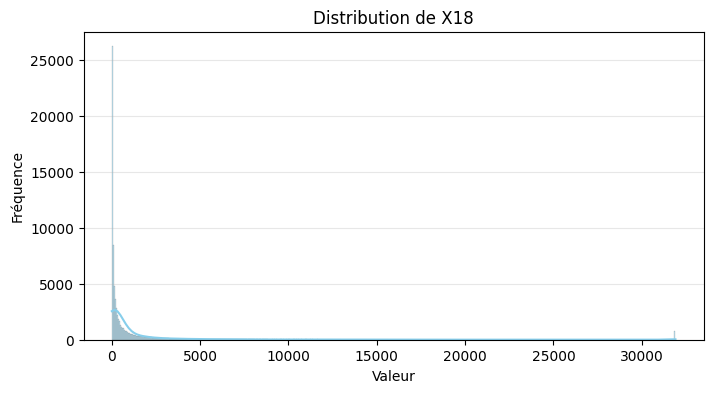

In [29]:
features_to_plot = [col for col in df.columns if col.startswith('X')]

print("Visualisation des distributions des ratios financiers...")

for col in features_to_plot:
    plt.figure(figsize=(8, 4))
    # Utilisation de histplot avec kde=True pour la courbe de densité
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution de {col}')
    plt.xlabel('Valeur')
    plt.ylabel('Fréquence')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

Explication: on observe que l'immense majorité des entreprises est regroupée au début, et une toute petite poignée (les géants comme apple ..) s'étire vers des chiffres astronomiques. En statistiques, on appelle cela une distribution fortement asymétrique à droite----> on doit obligatoirement faire la standarisation

In [30]:
featuers_columns=[col for col in data.columns if col.startswith('X')]

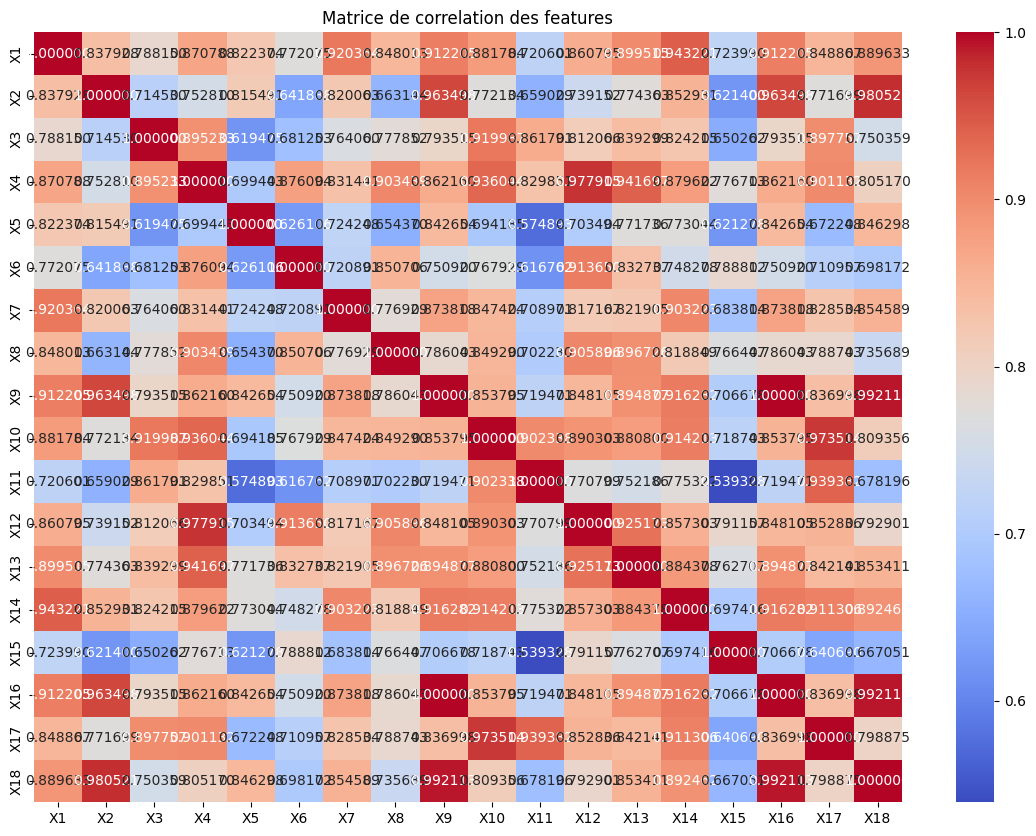

In [31]:
plt.figure(figsize=(14,10))
sns.heatmap(df[featuers_columns].corr(),annot=True,cmap='coolwarm',fmt='2f')
plt.title('Matrice de correlation des features')
plt.show()

ON OBSERVE que X16 et X18 sont redondantes avec X9 ---> supprimer les deux variable (Feature Redundancy)

In [32]:
cols_to_drop = ['X16', 'X18']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Variables supprimées avec succès : {cols_to_drop}")
else:
    print("Les colonnes sont déjà supprimées.")

# Mise à jour de votre liste de features comptables
features_comptables = [f'X{i}' for i in range(1, 19) if f'X{i}' not in cols_to_drop]

Variables supprimées avec succès : ['X16', 'X18']


In [33]:
features_comptables

['X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'X8',
 'X9',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X17']

Train-Test Split (Découpage Groupé par Entreprise (Train/Test)

In [34]:
X=df.drop(['status_label', 'company_name'],axis=1)
y=df['status_label']

In [35]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['company_name']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [36]:
print(f"Nombre d'entreprises uniques dans le Train : {df.iloc[train_idx]['company_name'].nunique()}")
print(f"Nombre d'entreprises uniques dans le Test : {df.iloc[test_idx]['company_name'].nunique()}")

Nombre d'entreprises uniques dans le Train : 7176
Nombre d'entreprises uniques dans le Test : 1795


on a deja observer qu'il ya des chiffre tres grande et des chirffres tres petites---> standardisation des variables(RobustScaler)

In [37]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
print(X_train_scaled.head())

   year        X1        X2        X3        X4        X5        X6        X7  \
0  -0.8 -0.219465 -0.135194 -0.154012 -0.107632 -0.020609 -0.078494 -0.145915   
1  -0.7 -0.223970 -0.140441 -0.153309 -0.101017 -0.039185 -0.049432 -0.151140   
2  -0.6 -0.227313 -0.141727 -0.152010 -0.103071 -0.046925 -0.068751 -0.155496   
3  -0.5 -0.228650 -0.146162 -0.160656 -0.100742 -0.055740 -0.030901 -0.157125   
4  -0.3 -0.228965 -0.147599 -0.164809 -0.094367 -0.057209 -0.004705 -0.156826   

         X8        X9  ...  INFLATION(%)  MORTGAGE INT. MONTHLY AVG(%)  \
0 -0.182193 -0.153734  ...     -0.061070                      0.738827   
1 -0.181133 -0.157615  ...      0.733169                      1.020241   
2 -0.182421 -0.158891  ...      0.369143                      0.522000   
3 -0.183558 -0.162735  ...     -0.376092                      0.221642   
4 -0.173479 -0.162982  ...      0.267124                      0.000000   

   MED HOUSEHOLD INCOME  CORP. BOND YIELD(%)  MONTHLY HOME SUPPLY  \

Resoudre le Desequilibre des classes :

In [38]:
data['status_label'].value_counts(normalize=True) # notre dataset est fortement desiquilibre(93,4% contre 6,6%)

status_label
alive     0.933657
failed    0.066343
Name: proportion, dtype: float64

pour resoudre le probleme de desequilibre , on a plusieurs methode : utilise le SMOTE par exemple qui va inventer de nouveaux cas realiste en se basant sur un exemple du classe minoritaire et il cherche ses voisins les plus proches et il trace une ligne entre ces deux point --> il place un nouveau point n'importe ou sur cette ligne , cette methode peut etre utiliser pour les simple modele comme XGBoost , mais pas pour LSTM puisque il va pas respecter la correlation inter-annuelle(les donnes financier de 2024 doit etre compatible avec 2023...) il peut donner une nouvelle entreprise hybride entre deux entreprise differents-->evolution n'a jamais existe.

* SMOTE 

In [39]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Application du SMOTE sur le Train...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Nouvelles dimensions : {X_train_resampled.shape}")

Application du SMOTE sur le Train...
Nouvelles dimensions : (117890, 31)


entrainement de notre premier modele:XGBoost+Smote

In [40]:
# Initialisation du modèle
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Entraînement
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Evaluation de notre premier modele

In [41]:
# Prédictions
y_pred = xgb_model.predict(X_test_scaled)

# Rapport de performance
print("\nRésultats XGBoost (avec SMOTE) :")
print(classification_report(y_test, y_pred))


Résultats XGBoost (avec SMOTE) :
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     14517
           1       0.14      0.55      0.23      1177

    accuracy                           0.72     15694
   macro avg       0.55      0.64      0.53     15694
weighted avg       0.89      0.72      0.78     15694



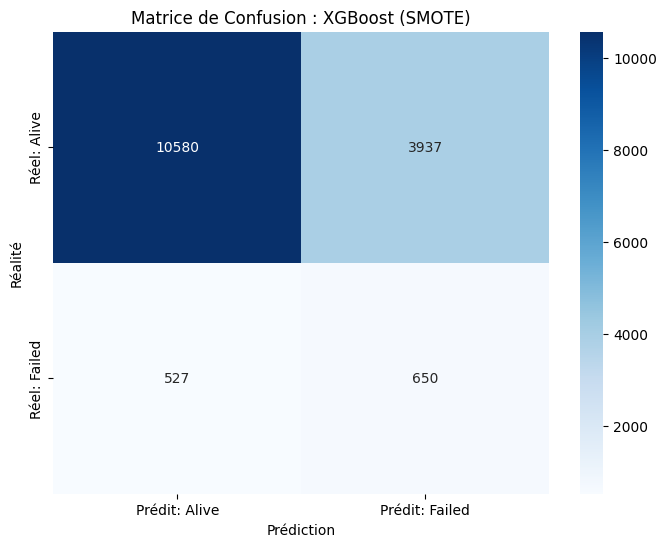

In [42]:
cm = confusion_matrix(y_test, y_pred)

# 2. Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit: Alive', 'Prédit: Failed'], 
            yticklabels=['Réel: Alive', 'Réel: Failed'])
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.title('Matrice de Confusion : XGBoost (SMOTE)')
plt.show()

In [43]:
# 1. On calcule le ratio entre les deux classes
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. On passe ce ratio au modèle
model_pondere = XGBClassifier(
    scale_pos_weight=ratio, 
    n_estimators=100, 
    random_state=42
)

# 3. On entraîne sur les données RÉELLES uniquement
model_pondere.fit(X_train_scaled, y_train)

# 4. On compare les résultats
y_pred_pondere = model_pondere.predict(X_test_scaled)
print(classification_report(y_test, y_pred_pondere))

              precision    recall  f1-score   support

           0       0.94      0.87      0.91     14517
           1       0.19      0.36      0.25      1177

    accuracy                           0.84     15694
   macro avg       0.57      0.62      0.58     15694
weighted avg       0.89      0.84      0.86     15694



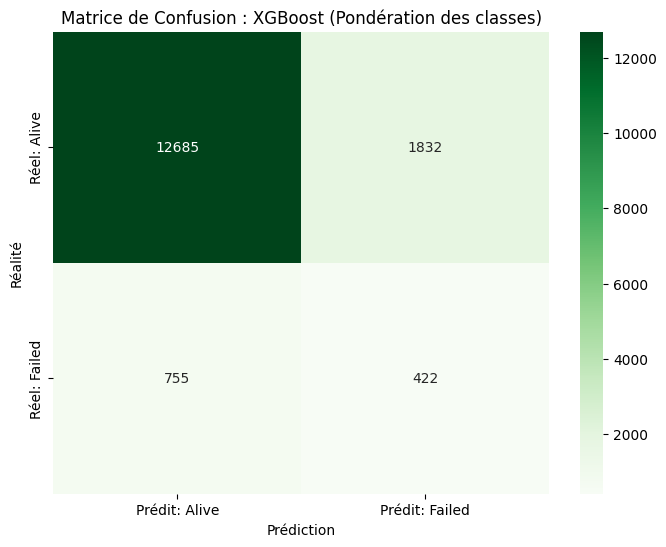

In [44]:
# 1. Calcul de la matrice avec les prédictions pondérées
cm_pondere = confusion_matrix(y_test, y_pred_pondere)

# 2. Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pondere, annot=True, fmt='d', cmap='Greens', # 'Greens' pour changer de couleur
            xticklabels=['Prédit: Alive', 'Prédit: Failed'], 
            yticklabels=['Réel: Alive', 'Réel: Failed'])
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.title('Matrice de Confusion : XGBoost (Pondération des classes)')
plt.show()

In [45]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
# 1. Configuration (5 plis pour une validation robuste)
# on utiliser TimeSeriesSplit puisque ona la notion d'ordre temporel
tscv = TimeSeriesSplit(n_splits=5)

# On suppose que 'model_pondere' est déjà défini avec scale_pos_weight
scores = cross_val_score(model_pondere, X_train_scaled, y_train, cv=tscv, scoring='f1')

# 3. Analyse des résultats
print(f"Scores F1 sur chaque bloc : {scores}")
print(f"Moyenne de précision du modèle : {np.mean(scores):.4f}")
print(f"Stabilité (écart-type) : {np.std(scores):.4f}")

Scores F1 sur chaque bloc : [0.14843007 0.13441296 0.12327947 0.1563745  0.2574605 ]
Moyenne de précision du modèle : 0.1640
Stabilité (écart-type) : 0.0481


In [77]:
X_train_scaled

,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,-0.8,-0.219465,-0.135194,-0.154012,-0.107632,-0.020609,-0.078494,-0.145915,-0.182193,-0.153734,...,-0.061070,0.738827,-0.996283,0.683535,-0.284698,-0.672932,-0.876887,-0.875905,7.604789,-1.266942
1,-0.7,-0.223970,-0.140441,-0.153309,-0.101017,-0.039185,-0.049432,-0.151140,-0.181133,-0.157615,...,0.733169,1.020241,-0.846422,0.950738,-0.224199,-0.298536,-0.797858,-0.602948,6.481760,-1.075625
2,-0.6,-0.227313,-0.141727,-0.152010,-0.103071,-0.046925,-0.068751,-0.155496,-0.182421,-0.158891,...,0.369143,0.522000,-0.818541,0.702319,-0.302491,-0.423335,-0.738033,-0.536375,0.679444,-0.934654
3,-0.5,-0.228650,-0.146162,-0.160656,-0.100742,-0.055740,-0.030901,-0.157125,-0.183558,-0.162735,...,-0.376092,0.221642,-0.797746,0.392371,-0.307829,-0.181731,-0.666030,-0.885295,-0.529319,2.007145
4,-0.3,-0.228965,-0.147599,-0.164809,-0.094367,-0.057209,-0.004705,-0.156826,-0.173479,-0.162982,...,0.267124,0.000000,-0.574117,0.033353,-0.323843,0.227695,-0.403619,-0.452860,0.358881,0.809360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62983,0.7,2.098989,1.724037,0.768865,2.995447,4.637817,3.606947,1.820896,4.159314,1.871887,...,-0.430453,-0.768429,0.508945,-0.640981,0.306050,-0.526045,0.575396,0.798771,0.000000,-0.382490
62984,0.8,1.524933,1.640143,0.860444,3.029332,2.584786,3.164462,2.155131,4.987263,1.823208,...,-1.425250,-0.917825,0.841078,-0.767874,0.174377,-0.780412,0.694087,1.025260,-0.320556,-0.307689
62985,0.9,1.751477,1.731852,1.139439,3.353360,2.801240,4.726662,1.913099,4.799111,1.987959,...,-0.668765,-1.010688,1.134178,-0.869465,0.192171,-1.071396,0.773226,1.168584,-0.261292,0.000000
62986,1.0,2.240640,1.858171,1.154347,3.899054,3.053113,5.644870,2.196623,5.997050,2.153001,...,-0.093094,-0.852315,1.377788,-0.833813,0.266904,-1.392707,0.921202,1.365698,0.067041,0.219781


application de SHAP sur XGBoost pour interpreter les resultet et comprendre l'importance et la reponsabilite de chaque variable sur la prediction

/tmp/ipykernel_58/2380749078.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_scaled,max_display=54)


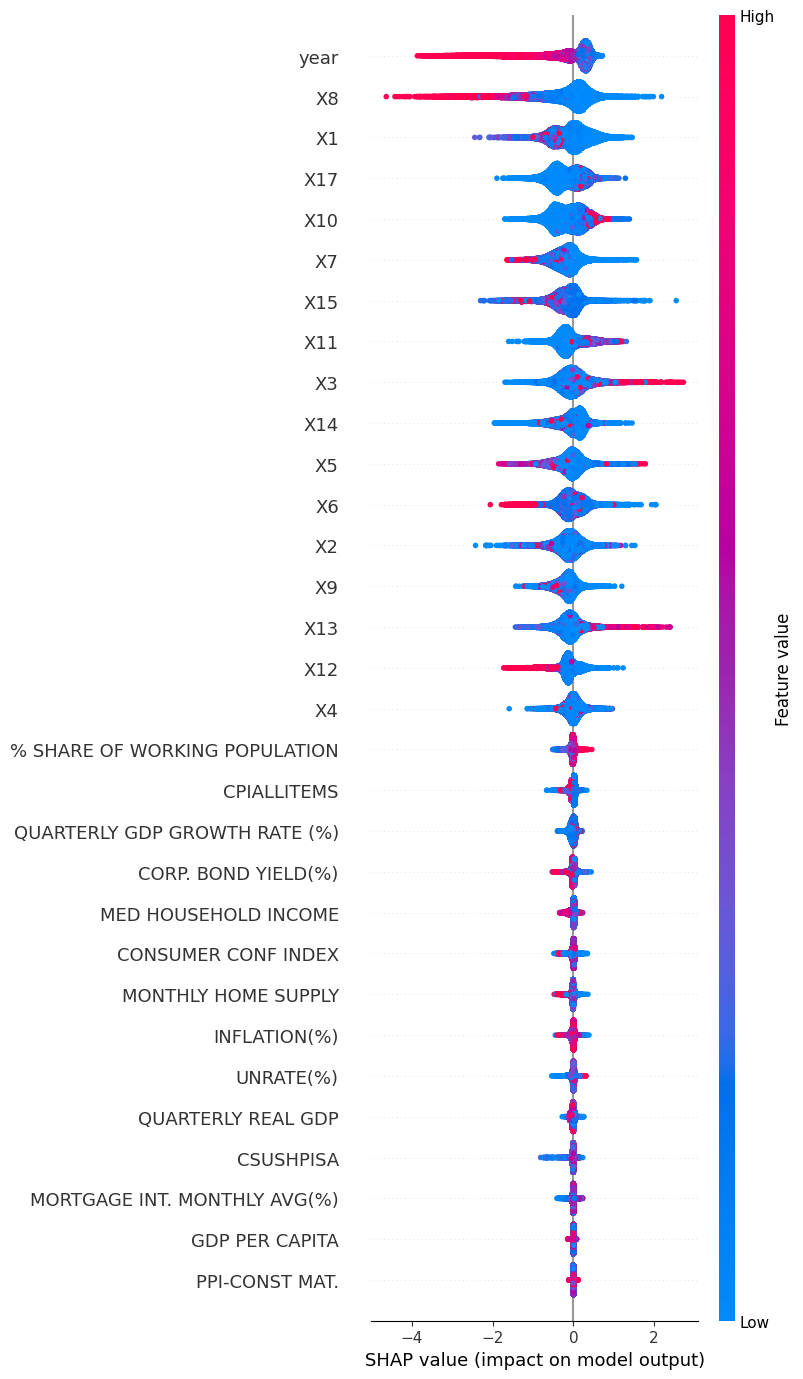

In [78]:
import shap
# 1. Initialiser le TreeExplainer
explainer = shap.TreeExplainer(model_pondere)

# 2. Calculer les valeurs SHAP
# Ici, pas besoin de wrapper, pas besoin de background manuel
# On passe directement les données d'entraînement (ou de test)
shap_values = explainer.shap_values(X_train_scaled)

# 3. Visualisation : Le Summary Plot (Beeswarm)
# C'est le meilleur graphique pour voir l'impact de chaque variable
shap.summary_plot(shap_values, X_train_scaled,max_display=54)

d'apres de ce graphe on observe que les donnees macro economique n'a pas une grande influence sur la faillite ou non d'une entreprise ,en revanche , il ya des variable comme X8 qui influence bcp plus cette variable augmente plus il diminue le probabilite qu'une entreprise fera faillite et vise versa. par contre on observant X3 et X13 , on peut dire ils poussent les entreprise a leurs faillite s'ils augmentent....

* analyse locale par Waterfall plot

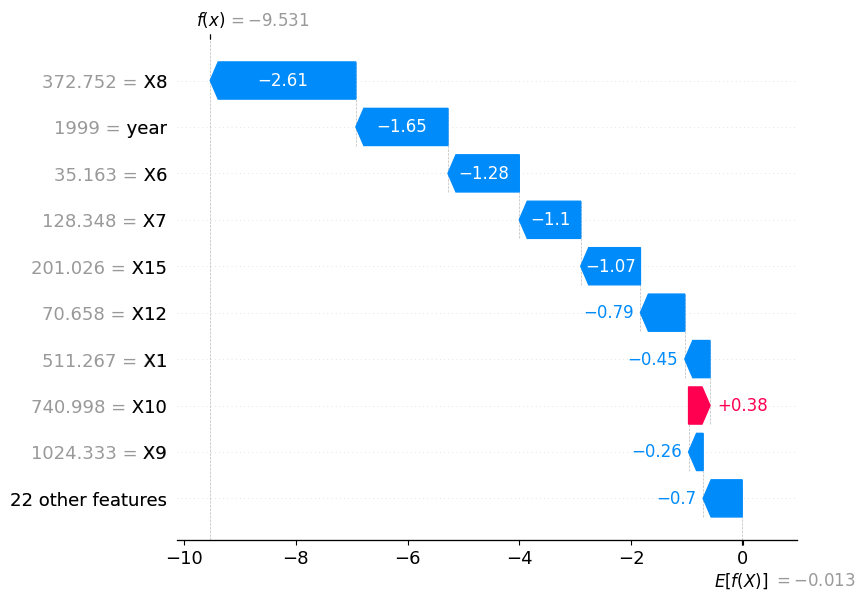

In [79]:
shap_values_obj = explainer(X_test) # Utilisez X_test_scaled

# 2. Afficher le Waterfall pour la première entreprise du test set
shap.plots.waterfall(shap_values_obj[0])

pour cette entreprise, le modèle a abaissé le score de risque de -9.531. Cela est principalement dû à la valeur de X8 (-2.61) et du year (-1.65), qui agissent ici comme des facteurs de réduction du risque. À l'inverse, X10 a eu un effet légèrement aggravant (+0.38)."

***L'Analyse Temporelle Spécifique (Préparation au LSTM)***

notre objectif est d'utiliser le LSTM puisque on a des sequence temporelle mais d'abord on doit verifier la structure du temps


1. Combien d'annes d'historique pour chaque entreprise?
2. Est-ce que le nombre de faillites varie selon les années ?


count    8971.000000
mean        8.770706
std         6.421565
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        20.000000
Name: year, dtype: float64


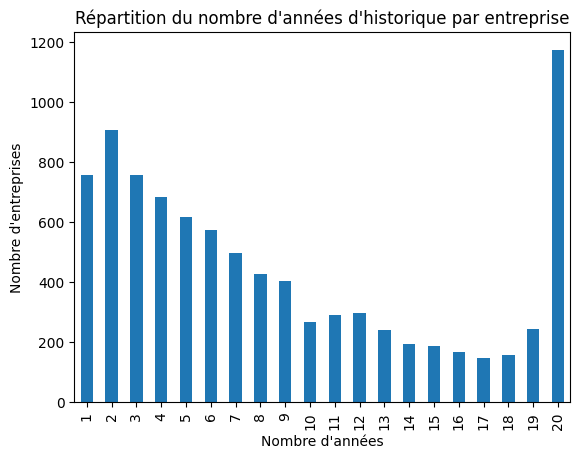

In [46]:
years_company=df.groupby('company_name')['year'].count()
print(years_company.describe())

import matplotlib.pyplot as plt
years_company.value_counts().sort_index().plot(kind='bar')
plt.title("Répartition du nombre d'années d'historique par entreprise")
plt.xlabel("Nombre d'années")
plt.ylabel("Nombre d'entreprises")
plt.show()


***puisque les 25% premier des entreprise ont entre 1an et 3ans, donc 75% ont deja 3ans d'historique --> la majorite ont 3ans d'historique***

In [47]:
years_per_company=df.groupby('company_name')['year'].transform('count')
data_filtered=data[years_per_company>=3].copy()
print("Nombre de lignes avant filtrage :", len(data))
print("Nombre de lignes après filtrage :", len(data_filtered))
print("Nombre d'entreprises uniques restantes :", data_filtered['company_name'].nunique())



Nombre de lignes avant filtrage : 78682
Nombre de lignes après filtrage : 76115
Nombre d'entreprises uniques restantes : 7310


In [48]:
data_filtered

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,alive,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,104.223,1099.101,184.666,31.521,60.885,28.197,28.095,104.223,225.887,58.608
78678,C_8971,alive,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,291.153,1865.926,770.103,159.541,231.969,88.128,157.783,291.153,880.327,89.020
78679,C_8971,alive,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,169.858,1746.235,683.985,13.994,100.784,85.765,156.341,169.858,770.233,90.807
78680,C_8971,alive,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,161.884,1736.110,694.035,3.841,95.357,82.010,135.941,161.884,776.697,92.713


Vérifier s'il y a des trous ou des années vides

/tmp/ipykernel_58/2952070537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_filtered,x='year',palette='viridis')


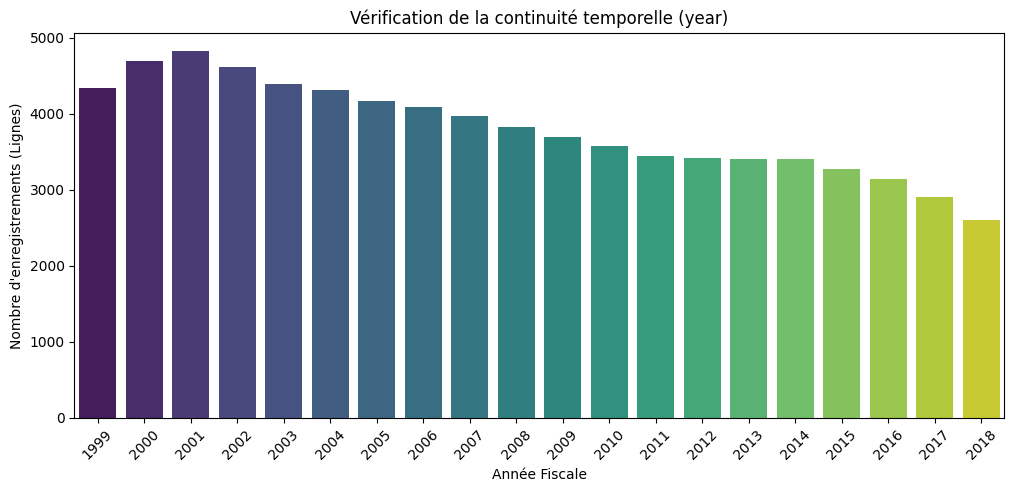

In [49]:
plt.figure(figsize=(12,5))
sns.countplot(data=data_filtered,x='year',palette='viridis')
plt.title('Vérification de la continuité temporelle (year)')
plt.xlabel('Année Fiscale')
plt.ylabel("Nombre d'enregistrements (Lignes)")
plt.xticks(rotation=45)
plt.show()

transforme status_label en chiffres (0 et 1)

In [50]:
data_filtered['status_label']=data_filtered['status_label'].map({'alive':0,'failed':1})

In [51]:
data_filtered

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,0,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,104.223,1099.101,184.666,31.521,60.885,28.197,28.095,104.223,225.887,58.608
78678,C_8971,0,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,291.153,1865.926,770.103,159.541,231.969,88.128,157.783,291.153,880.327,89.020
78679,C_8971,0,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,169.858,1746.235,683.985,13.994,100.784,85.765,156.341,169.858,770.233,90.807
78680,C_8971,0,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,161.884,1736.110,694.035,3.841,95.357,82.010,135.941,161.884,776.697,92.713


**creation des sequences pour le LSTM**

In [52]:
import pickle
import numpy as np
from sklearn.preprocessing import RobustScaler

# ─── 1. Fonction create_lstm_sequences ───
def create_lstm_sequences(df, time_steps=3):
    X, Y = [], []
    feature_cols = [col for col in df.columns 
                    if col.startswith('X') or col.startswith('Div_')]
    for company, group in df.groupby('company_name'):
        group = group.sort_values('year')
        years    = group['year'].values
        features = group[feature_cols].values
        labels   = group['status_label'].values
        for i in range(len(group) - time_steps):
            if years[i + time_steps] == years[i] + time_steps:
                X.append(features[i : i + time_steps])
                Y.append(labels[i + time_steps])
    return np.array(X), np.array(Y)

# ─── 2. Split par entreprise ───
companies = data_filtered['company_name'].unique()
np.random.seed(42)
np.random.shuffle(companies)  # ← shuffle pour éviter biais

n = len(companies)
train_cos = companies[:int(n * 0.70)]
val_cos   = companies[int(n * 0.70):int(n * 0.85)]
test_cos  = companies[int(n * 0.85):]

df_train = data_filtered[data_filtered['company_name'].isin(train_cos)].copy()
df_val   = data_filtered[data_filtered['company_name'].isin(val_cos)].copy()
df_test  = data_filtered[data_filtered['company_name'].isin(test_cos)].copy()

print(f"Entreprises train : {len(train_cos)}")
print(f"Entreprises val   : {len(val_cos)}")
print(f"Entreprises test  : {len(test_cos)}")

# ─── 3. Normalisation ───
feature_cols = [col for col in data_filtered.columns 
                if col.startswith('X') or col.startswith('Div_')]

scaler = RobustScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols]   = scaler.transform(df_val[feature_cols])
df_test[feature_cols]  = scaler.transform(df_test[feature_cols])

# Sauvegarder le scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ─── 4. Séquences ───
X_train_seq, y_train_seq = create_lstm_sequences(df_train, time_steps=3)
X_val_seq,   y_val_seq   = create_lstm_sequences(df_val,   time_steps=3)
X_test_seq,  y_test_seq  = create_lstm_sequences(df_test,  time_steps=3)

print(f"X_train_seq : {X_train_seq.shape}")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")



Entreprises train : 5117
Entreprises val   : 1096
Entreprises test  : 1097
X_train_seq : (36765, 3, 18)
X_val_seq   : (8419, 3, 18)
X_test_seq  : (7507, 3, 18)


choix de l'architecture , on commence tjrs par une archi simple et efficace( 1 couche LSTM,couche dropout ,couche dense)

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

model = Sequential([
    LSTM(32, 
         input_shape=(3, X_train_seq.shape[2]), 
         return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),  # ← couche dense intermédiaire
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,617 (29.75 KB)

 Trainable params: 7,617 (29.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculer automatiquement le déséquilibre des classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq  
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print("Poids appliqués pour équilibrer :", class_weight_dict)

# 2. Entraînement
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    verbose=1
)

In [ ]:

# 1. Graphique de la Perte (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la Perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()

# 2. Graphique de l'AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Évolution de l\'AUC')
plt.xlabel('Époques')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 1. Prédictions sur le jeu de test
y_pred_probs = model.predict(X_test_seq)       
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Calcul de la matrice
cm = confusion_matrix(y_test_seq, y_pred)         
# 3. Affichage graphique
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Sain', 'Prédit Faillite'],
            yticklabels=['Réel Sain', 'Réel Faillite'])
plt.title('Matrice de Confusion Équilibrée')
plt.ylabel('Réalité')
plt.xlabel('Prédiction du LSTM')
plt.show()

# 4. Rapport complet
print(classification_report(y_test_seq, y_pred))  

In [ ]:
model.save('meilleur_modele_lstm.keras')
print("Modèle enregistré avec succès !")


SHAP (SHapley Additive exPlanations):attribuer à chaque variable une part de responsabilité dans la prédiction finale.

* SHAP Globales (Compréhension générale du modèle)
L'interprétation globale cherche à comprendre comment le modèle se comporte dans son ensemble, en agrégeant les explications locales.

In [81]:
import shap
import numpy as np

# 1. Préparation des données aplaties (2D) pour SHAP
# Votre modèle attend (Batch, 3, 18)
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1) 

# 2. Création de la fonction Wrapper (LE POINT CRUCIAL)
def model_predict_wrapper(data_flat):
    # 1. Remodeler en 3D
    data_3d = data_flat.reshape(-1, 3, 18)
    
    # 2. Si votre modèle exige absolument une taille de batch fixe (ex: 32)
    # on complète avec des lignes vides (padding) si nécessaire
    batch_size = 32
    n_samples = data_3d.shape[0]
    
    if n_samples < batch_size:
        # Créer des données de remplissage (zéros)
        padding = np.zeros((batch_size - n_samples, 3, 18))
        data_3d_padded = np.concatenate([data_3d, padding], axis=0)
        predictions = model.predict(data_3d_padded, verbose=0)
        return predictions[:n_samples] # On ne renvoie que les prédictions réelles
    
    return model.predict(data_3d, verbose=0)

# 3. Création du background 2D
background = X_train_flat[np.random.choice(X_train_flat.shape[0], 50, replace=False)]

# 4. Initialisation du KernelExplainer avec le wrapper
# On passe la FONCTION, pas model.predict
explainer = shap.KernelExplainer(model_predict_wrapper, background)

# 5. Calcul des valeurs SHAP
# On passe des données 2D
shap_values = explainer.shap_values(X_test_flat[:100])

Provided model function fails when applied to the provided data set.


KeyError: Input Parameters:
  data (POSITIONAL_OR_KEYWORD): List[TensorSpec(shape=(32, 3, 18), dtype=tf.float32, name=None)]
Output Type:
  None
Captures:
  None

In [80]:
shap.summary_plot(shap_values, X_test_flat[:100],max_display=6)

/tmp/ipykernel_58/2546713665.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_flat[:100],max_display=6)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
# Affiche l'explication pour l'entreprise n°0
shap.waterfall_plot(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X_test_flat[0]))

j'ai pas arrivé a eppliquer SHAP sur LSTM puisque le LSTM attent des sequences 3D et SHAP attent des donnees de 2D  c'est pour cela je vais utiliser une autre methode dinterpretabilite : **permutation impotance**

Attention: Correction de la taille de y_test (15694 -> 7507)
Score de référence (Accuracy) : 0.6217
Variable 0 traitée...
Variable 1 traitée...
Variable 2 traitée...
Variable 3 traitée...
Variable 4 traitée...
Variable 5 traitée...
Variable 6 traitée...
Variable 7 traitée...
Variable 8 traitée...
Variable 9 traitée...
Variable 10 traitée...
Variable 11 traitée...
Variable 12 traitée...
Variable 13 traitée...
Variable 14 traitée...
Variable 15 traitée...
Variable 16 traitée...
Variable 17 traitée...


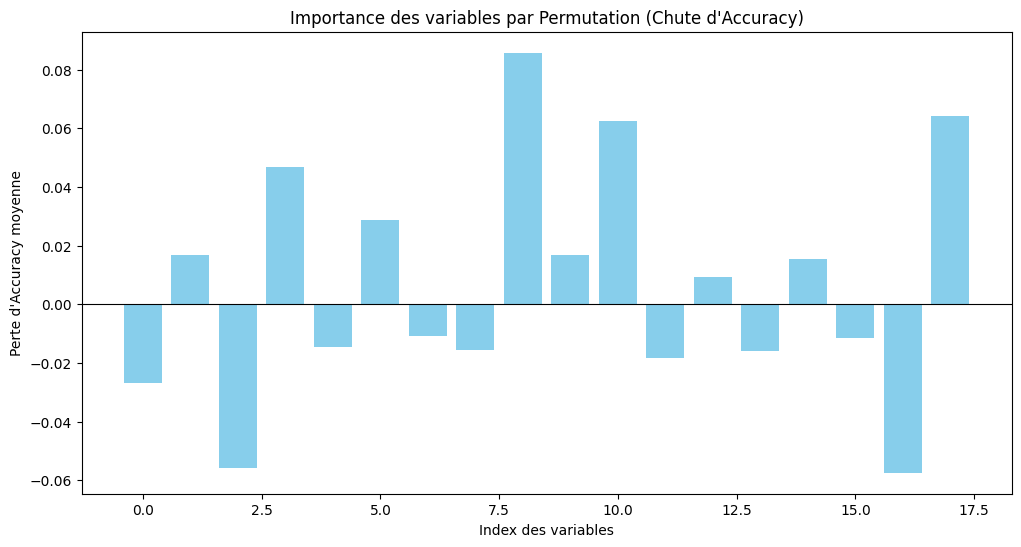

In [85]:


def get_permutation_importance(model, X_test_3d, y_test, num_repeats=5):
    """
    Calcule l'importance des variables par permutation pour un modèle LSTM.
    """
    # 1. Vérification de la cohérence des données
    n_samples = X_test_3d.shape[0]
    if y_test.shape[0] != n_samples:
        print(f"Attention: Correction de la taille de y_test ({y_test.shape[0]} -> {n_samples})")
        y_test = y_test[:n_samples]
    
    # 2. Calcul du score de référence (Accuracy)
    # model.evaluate retourne [loss, accuracy, recall, auc, precision]
    baseline_score = model.evaluate(X_test_3d, y_test, verbose=0)[1] 
    print(f"Score de référence (Accuracy) : {baseline_score:.4f}")
    
    importances = []
    n_features = X_test_3d.shape[2]
    
    # 3. Boucle sur chaque variable (colonne)
    for col in range(n_features):
        scores = []
        for _ in range(num_repeats):
            # Copie pour préserver les données originales
            X_permuted = X_test_3d.copy()
            # Mélange de la colonne 'col' sur tous les pas de temps
            np.random.shuffle(X_permuted[:, :, col])
            
            # Calcul du nouveau score après permutation
            score = model.evaluate(X_permuted, y_test, verbose=0)[1]
            scores.append(baseline_score - score)
        
        # L'importance est la baisse moyenne de performance
        importances.append(np.mean(scores))
        print(f"Variable {col} traitée...")
        
    return importances

# EXECUTION 
# Assurez-vous que X_test_seq est bien au format (N, 3, 18)
importances = get_permutation_importance(model, X_test_seq, y_test)

# --- VISUALISATION ---
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances, color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Importance des variables par Permutation (Chute d'Accuracy)")
plt.xlabel("Index des variables")
plt.ylabel("Perte d'Accuracy moyenne")
plt.show()